<a href="https://colab.research.google.com/github/ARADHYA299/ML-PROJECTS/blob/main/NEURALNETWORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%tensorflow_version 2.x
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

print(tf.__version__)
print(keras.__version__)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
2.18.0
3.8.0


In [2]:
fashion = keras.datasets.fashion_mnist
(train_images , train_labels) , (test_images , test_labels) = fashion.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
train_images.shape

(60000, 28, 28)

In [4]:
test_images.shape

(10000, 28, 28)

In [5]:
train_labels[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

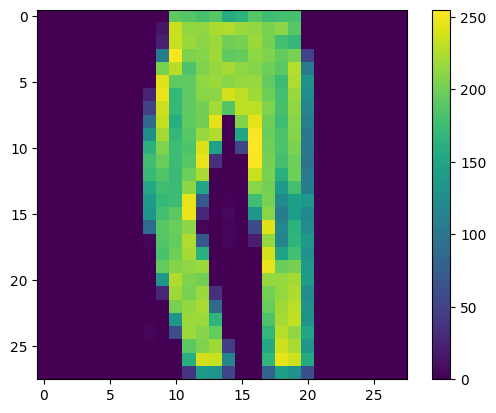

In [7]:
plt.figure()
plt.imshow(test_images[5])
plt.colorbar()
plt.show()

In [8]:
train_images = train_images / 255.0
test_images = test_images / 255.0
train_images.shape

(60000, 28, 28)

In [9]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (28,28)),
    keras.layers.Dense(128 , activation="relu"),
    keras.layers.Dense(10 , activation="softmax")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
print(len(train_images))  # Should be 1875 if batch_size=32
print(sum(len(batch) for batch in train_images))  # Should be 60,000


60000
1680000


In [11]:
model.compile(optimizer="adam" , loss = "sparse_categorical_crossentropy" ,metrics=['accuracy'])



```
`# This is formatted as code`
```



In [12]:
model.fit(train_images, train_labels , epochs=1)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7758 - loss: 0.6264


In [13]:
test_loss , test_accuracy = model.evaluate(test_images , test_labels , verbose = 1)
print("Test accuracy:" , test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8508 - loss: 0.4350
Test accuracy: 0.8440999984741211


In [14]:
predictions = model.predict(test_images)
print(predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[1.96724111e-04 5.12795850e-06 3.70414600e-05 ... 1.25766754e-01
  7.66093051e-03 8.24920416e-01]
 [2.24831223e-04 5.98998611e-07 9.74484861e-01 ... 1.08339740e-10
  1.65570564e-05 1.02899682e-10]
 [1.30099925e-05 9.99947727e-01 9.29669113e-07 ... 1.43858883e-10
  1.38131124e-08 5.04226272e-10]
 ...
 [1.08767962e-02 9.31429952e-07 2.73594691e-04 ... 2.60755087e-06
  9.80813861e-01 3.81924309e-07]
 [3.09464895e-06 9.99095082e-01 4.86484805e-06 ... 7.48533324e-08
  1.55932497e-07 2.25009558e-06]
 [3.10545089e-03 2.02538504e-04 3.86715960e-03 ... 1.90801069e-01
  1.50510192e-01 1.77475493e-02]]


In [15]:
np.argmax(predictions[0])

9

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Sneaker


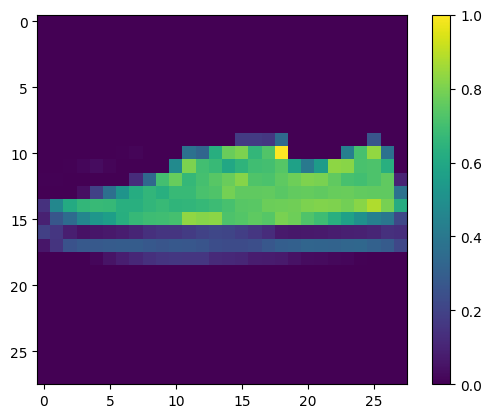

In [18]:
predictions = model.predict(test_images)
print(class_names[np.argmax(predictions[789])])
plt.figure()
plt.imshow(test_images[789])
plt.colorbar()
plt.show()